# 2. Análisis exploratorio de datos (EDA)
2.1 Entendimiento general de los datos.


In [ ]:
import sys
from pathlib import Path
import os
import seaborn as sns
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from src.extraccion import Extraccion


In [ ]:
print("Iniciando...\n")
# Inserción de la ruta del proyecto.
sys.path.insert(0, str(Path.cwd().parent))

# Llamado de la clase Extracción para obtener los dataset.

# Configuración básica para visualizar mejor las tablas.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

# Instanciamos y extraemos
extractor = Extraccion()
extractor.conectar_mongodb()
dfs = extractor.extraer_datos()


# Separamos los DataFrames para mayor comodidad en el EDA.
df_listings = dfs.get("Listings", pd.DataFrame())
df_reviews = dfs.get("Reviews", pd.DataFrame())
df_calendar = dfs.get("Calendar", pd.DataFrame())

print("Datos cargados correctamente en el Notebook.")

Iniciando...



2026-04-09 10:31:40,939 - INFO - Conexión a MongoDB establecida exitosamente, base de datos seleccionada: airbnb_mx
2026-04-09 10:31:40,940 - INFO - Iniciando consulta de la colección: Listings


Conexión a MongoDB establecida exitosamente, base de datos seleccionada: airbnb_mx


2026-04-09 10:31:43,004 - INFO - Extracción completada. 27348 registros cargados exitosamente de 'Listings'.
2026-04-09 10:31:43,007 - INFO - Iniciando consulta de la colección: Reviews
2026-04-09 10:31:56,443 - INFO - Extracción completada. 1042702 registros cargados exitosamente de 'Reviews'.
2026-04-09 10:31:56,444 - INFO - Iniciando consulta de la colección: Calendar
2026-04-09 10:34:25,104 - INFO - Extracción completada. 14939072 registros cargados exitosamente de 'Calendar'.


Datos cargados correctamente en el Notebook.


## 2.1.1 Análisis de la colección: Listings
Esta colección contiene la información detallada de los alojamientos disponibles en Buenos Aires.

In [3]:
print(f"-Cantidad de registros y columnas: {df_listings.shape}.")

print("\n-Tipos de datos (info):")
df_listings.info()

print("\n-Primeras 5 filas")
display(df_listings.head())

-Cantidad de registros y columnas: (27348, 71).

-Tipos de datos (info):
<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 71 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27348 non-null  int64         
 1   listing_url                                   27348 non-null  str           
 2   scrape_id                                     27348 non-null  int64         
 3   last_scraped                                  27348 non-null  datetime64[us]
 4   source                                        27348 non-null  str           
 5   name                                          27348 non-null  str           
 6   description                                   26752 non-null  str           
 7   picture_url                                   27347 non-null  str           
 8   host

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_picture_url,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_location,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,host_about,license
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,7,2,5,11,True,https://a0.muscache.com/im/pictures/user/ba7f6...,3,None,True,True,San Nicolas,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[Kitchen, Air conditioning, Wifi, TV]",7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,True,30,35,36,244,2026-01-25,0,0,0,220,0,0,2,2,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,11,0,3,7,False,https://a0.muscache.com/im/users/25649070/prof...,1,None,True,True,San Nicolas,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[Paid parking on premises, Air conditioning, W...",2.0,365.0,2.0,2.0,365.0,365.0,2.0,365.0,True,7,16,32,307,2026-01-25,1,0,0,283,1,0,1,1,0,0,"Autonomous City of Buenos Aires, Argentina",2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0.08,NaN,NaN
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,8,3,7,10,False,https://a0.muscache.com/im/pictures/user/4e988...,1,None,True,True,Balvanera,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[Smoke alarm, Wifi, Kitchen, Fire extinguisher...",7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,True,0,21,51,326,2026-01-25,0,0,0,302,0,0,1,1,0,0,"Olivos, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Responsable amable atento y amigable,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,1462517876404348407,https://www.airbnb.com/users/profile/146251787...,Marian,14,2,14,1,False,https://a0

**Descripción de variables relevantes (Listings):**

* `id`: Identificador único del anuncio.
* `name / description`: Textos descriptivos del alojamiento.
* `host_id / host_name`: Información básica del anfitrión.
* `neighbourhood_cleansed`: Barrio donde se ubica la propiedad.
* `latitude / longitude`: Coordenadas geoespaciales.
* `room_type`: Tipo de espacio (Casa entera, habitación privada, etc.).
* `price`: Precio por noche (se observa que suele venir como texto con el símbolo $, requerirá transformación).
* `minimum_nights`: Noches mínimas de reserva (clave para detectar outliers).

## 2.1.2 Análisis de la colección: Reviews
Contiene las reseñas detalladas que los huéspedes han dejado en los alojamientos.

In [4]:
print(f"-Cantidad de registros y columnas: {df_reviews.shape}.")

print("\n-Tipos de datos (info):")
df_reviews.info()

print("\n-Primeras 5 filas")
display(df_reviews.head())

-Cantidad de registros y columnas: (1042702, 6).

-Tipos de datos (info):
<class 'pandas.DataFrame'>
RangeIndex: 1042702 entries, 0 to 1042701
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   listing_id     1042702 non-null  int64         
 1   id             1042702 non-null  int64         
 2   date           1042702 non-null  datetime64[us]
 3   reviewer_id    1042702 non-null  int64         
 4   reviewer_name  1042701 non-null  object        
 5   comments       1042702 non-null  object        
dtypes: datetime64[us](1), int64(3), object(2)
memory usage: 47.7+ MB

-Primeras 5 filas


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r<br/>\r<br/>Location: short wa...
1,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...
3,11508,6050019,2013-07-28,4600436,Tara,"The apartment was in a beautiful, modern build..."
4,11508,9328455,2013-12-22,3130017,Simon,My stay at Candela's apartment was very enjoya...


**Descripción de variables relevantes (Reviews):**

* `listing_id`: Llave foránea que conecta la reseña con el alojamiento en la tabla Listings.
* `id`: Identificador único de la reseña.
* `date`: Fecha en la que se realizó el comentario.
* `reviewer_id / reviewer_name`: Datos de quien escribe la reseña.
* `comments`: Texto libre con la opinión del usuario.

## 2.1.3 Análisis de la colección: Calendar
Muestra la disponibilidad y el precio proyectado de cada alojamiento a lo largo del año.

In [8]:
print(f"-Cantidad de registros y columnas: {df_calendar.shape}.")

print("\n-Tipos de datos (info):")
df_calendar.info()

print("\n-Primeras 5 filas")
display(df_calendar.head())

-Cantidad de registros y columnas: (9982072, 5).

-Tipos de datos (info):
<class 'pandas.DataFrame'>
RangeIndex: 9982072 entries, 0 to 9982071
Data columns (total 5 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   available       bool          
 3   minimum_nights  int64         
 4   maximum_nights  int64         
dtypes: bool(1), datetime64[us](1), int64(3)
memory usage: 314.1 MB

-Primeras 5 filas


,listing_id,date,available,minimum_nights,maximum_nights
0,11508,2026-01-26,False,3,1125
1,11508,2026-01-27,False,3,1125
2,11508,2026-01-28,False,3,1125
3,11508,2026-01-29,False,3,1125
4,11508,2026-01-30,False,3,1125


**Descripción de variables relevantes (Calendar):**

* `listing_id`: Llave foránea hacia la tabla Listings.
* `date`: Fecha específica del calendario.
* `available`: Variable booleana que indica si está disponible en esa fecha.
* `price`: Precio para esa fecha específica.
* `minimum_nights / maximum_nights`: Reglas de estadía para esa fecha en particular.

## 2.2. Calidad de los datos

### 2.2.1 Valores nulos y registros duplicados
Definición de estrategia para validar la cantidad de datos faltantes, nulos, duplicados para nuestras tres colecciones.

In [20]:
# Función para detección de valores nulos y duplicados.

def reporte_calidad(df, nombre_df):
    print(f"=== Reporte de Calidad de datos: {nombre_df} ===")


    CLAVES_DUPLICADOS = {
        "Listings":  ["id"],
        "Reviews":   ["id"],           # o ["listing_id", "date"] si no hay id propio
        "Calendar":  ["listing_id", "date"],
    }
        
    # 1. Validación de duplicados.
    # Convertimos temporalmente columnas de tipo lista/dict a string para poder compararlas.
    
    claves = [c for c in CLAVES_DUPLICADOS.get(nombre_df, []) if c in df.columns]

    if claves:
        n_dup = df.duplicated(subset=claves).sum()
        print(f"\n[Duplicados] Clave: {claves}")
        print(f"  Registros duplicados: {n_dup}")
    else:
        print(f"\n[Duplicados] No se definieron claves para '{nombre_df}'")
        
    # df_temp = df.copy()
    
    # for col in df_temp.columns:
    #     if df_temp[col].apply(lambda x: isinstance(x, (list, dict))).any():
    #         df_temp[col] = df_temp[col].astype(str)
            
    # duplicados = df_temp.duplicated().sum()
    # print(f"Registros duplicados: {duplicados}")
    
    # 2. Validación de nulos.
    
    nulos = df.isnull().sum()
    nulos_significativos = nulos[nulos > 0].sort_values(ascending=False)
    
    if nulos_significativos.empty:
        print("Valores nulos: No se encontraron valores nulos.")
    else:
        print("Columnas con valores nulos:")
        for col, cant in nulos_significativos.items():
            porcentaje = (cant / len(df)) * 100
            print(f" - {col}: |{cant}| nulos -> ({porcentaje:.2f}%)")
            
    print("-" * 40, "\n")

# Ejecución
reporte_calidad(df_listings, "Listings")
reporte_calidad(df_reviews, "Reviews")
reporte_calidad(df_calendar, "Calendar")

=== Reporte de Calidad de datos: Listings ===

[Duplicados] Clave: ['id']
  Registros duplicados: 0
Columnas con valores nulos:
 - license: |26886| nulos -> (98.31%)
 - host_about: |11783| nulos -> (43.09%)
 - host_location: |5783| nulos -> (21.15%)
 - review_scores_accuracy: |3304| nulos -> (12.08%)
 - review_scores_cleanliness: |3303| nulos -> (12.08%)
 - review_scores_rating: |3303| nulos -> (12.08%)
 - last_review: |3303| nulos -> (12.08%)
 - first_review: |3303| nulos -> (12.08%)
 - review_scores_communication: |3303| nulos -> (12.08%)
 - review_scores_location: |3303| nulos -> (12.08%)
 - review_scores_value: |3303| nulos -> (12.08%)
 - review_scores_checkin: |3303| nulos -> (12.08%)
 - reviews_per_month: |3303| nulos -> (12.08%)
 - description: |596| nulos -> (2.18%)
 - has_availability: |204| nulos -> (0.75%)
 - maximum_minimum_nights: |106| nulos -> (0.39%)
 - minimum_minimum_nights: |106| nulos -> (0.39%)
 - maximum_nights: |106| nulos -> (0.39%)
 - maximum_maximum_nights: |1

### 2.2.2 Análisis de Valores Atípicos (Outliers)
Nos enfocaremos en la tabla `Listings`, específicamente en las variables de negocio críticas: `price`, `minimum_nights` y `availability_365`. 

In [ ]:
#df_listings.columns
# Elimina espacios al inicio y al final de los nombres de todas las columnas

df_listings.columns = df_listings.columns.str.strip()

# Verifica ahora
if 'price' in df_listings.columns:
    print("¡Columna 'price' encontrada!")
else:
    print("Columnas disponibles:", df_listings.columns.tolist())

Columnas disponibles: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost', 'host_picture_url', 'host_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availa

Text(0, 0.5, 'Días disponibles al año')

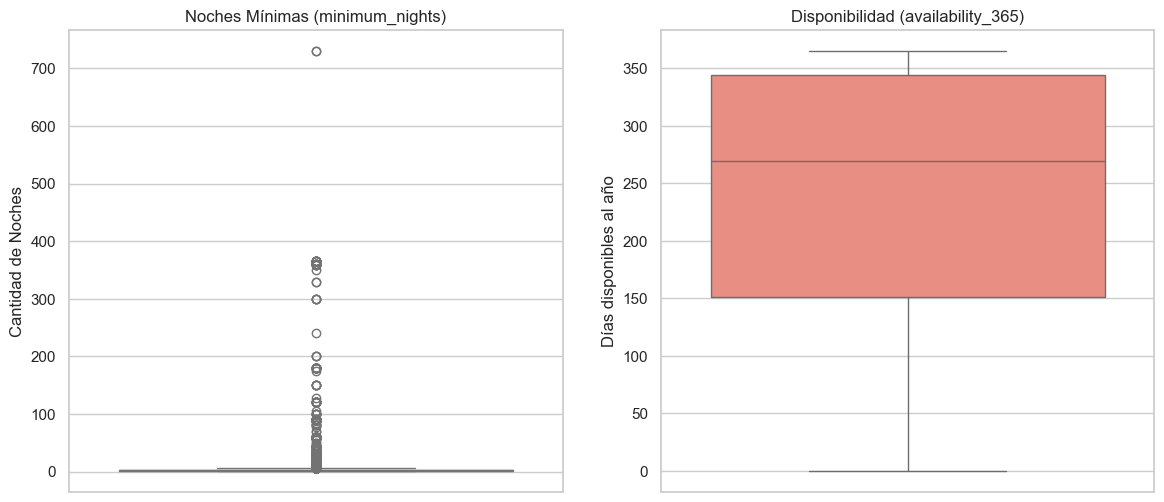

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=df_listings['minimum_nights'], ax=axes[0], color='lightgreen')
axes[0].set_title('Noches Mínimas (minimum_nights)')
axes[0].set_ylabel('Cantidad de Noches')

sns.boxplot(y=df_listings['availability_365'], ax=axes[1], color='salmon')
axes[1].set_title('Disponibilidad (availability_365)')
axes[1].set_ylabel('Días disponibles al año')

**Documentación de Hallazgos (Valores Atípicos):**

1. **`price`:** Presenta una consistencia de un 100% de valores nulos o vacios, la columna en su totalidad no tiene un valor asociado a un registro y no carga como campo en el df al momento de hacer un llamado al método extraccion.
2. **`minimum_nights`:** Se detectan valores ilógicos, llegando hasta una cantidad mínima de noches de 730 días. Probablemente son propiedades que ya no se rentan a corto plazo sino que buscan inquilinos fijos, o es un error de configuración. Estos extremos afectan el cálculo de estancias típicas.
3. **`availability_365`:** El rango va de 0 a 365. Llama la atención una alta concentración en el valor "0". Una disponibilidad de 0 días puede significar que el anuncio está inactivo, pausado por el anfitrión o completamente reservado. Esto no es contaría como error, pero es un patrón atípico que impactará el análisis de oferta de las productos activos.

C:\Users\david\AppData\Local\Temp\ipykernel_16532\2902668446.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_prop.values, y=top_prop.index, ax=axes[1], palette='viridis')


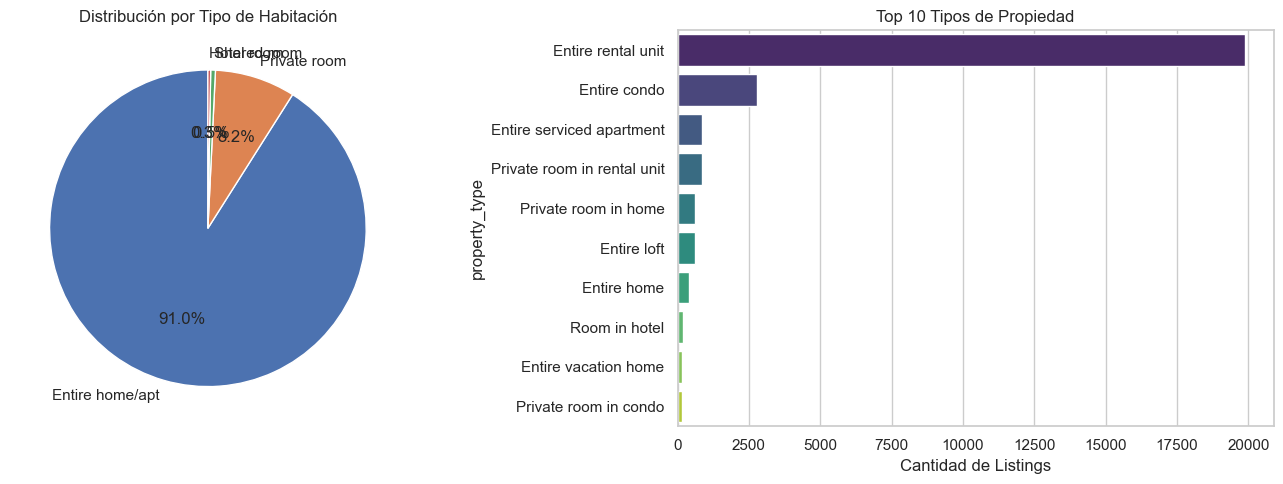

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Room type
room_counts = df_listings['room_type'].value_counts()
axes[0].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribución por Tipo de Habitación')

# Property type (Top 10)
top_prop = df_listings['property_type'].value_counts().head(10)
sns.barplot(x=top_prop.values, y=top_prop.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Tipos de Propiedad')
axes[1].set_xlabel('Cantidad de Listings')

plt.tight_layout()
plt.show()

In [37]:
room_counts = df_listings['room_type'].value_counts()
pct_room_type = room_counts / len(df_listings) * 100

print(f"Total de rooms: {len(df_listings)}")

# Mostrar cada tipo con su porcentaje
for room, pct in pct_room_type.items():
    print(f"{room}: {pct:.1f}%")


Total de rooms: 27348
Entire home/apt: 91.0%
Private room: 8.2%
Shared room: 0.5%
Hotel room: 0.3%


## Hallazgo: Tipo de Habitación

El **91%** de los listings son alojamientos completos (Entire home/apt), 
seguido por habitaciones privadas (**8.2%**) y compartidas (**0.5%**).

**Implicaciones para el análisis:**
- El dominio de alojamientos completos sugiere un mercado 
  orientado a turistas con capacidad de pago media-alta, 
  no a viajeros de bajo presupuesto.

**Decisiones de transformación que esto justifica:**
1. La columna `room_type` se conserva sin agrupar — tiene 
   poder discriminatorio real entre categorías.
2. La categorización de precios por rangos (Económico/Estándar/
   Alto/Premium) debe hacerse **dentro de cada room_type**, 
   no sobre el total, porque comparar precios de habitaciones 
   compartidas contra departamentos completos distorsiona los rangos.
3. Los listings con `room_type = Shared room` representan 
   menos del Z% — son candidatos a tratarse como segmento 
   separado o filtrarlos del análisis principal si el foco 
   es el mercado turístico estándar.

C:\Users\david\AppData\Local\Temp\ipykernel_16532\556051953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=barrios.values, y=barrios.index, palette='coolwarm', ax=ax)


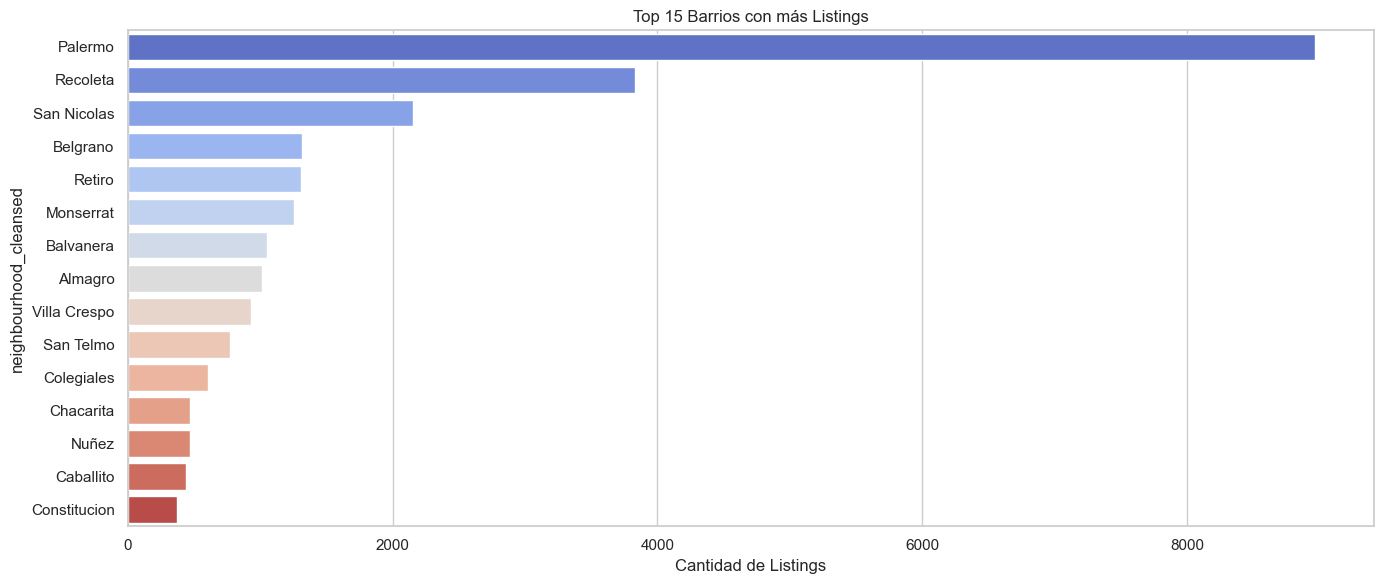

Total barrios únicos: 48
Palermo: 8,963 listings (32.8% del total)
Top 3 barrios: 54.7% del total
Top 15 barrios: 91.2% del total


In [45]:
fig, ax = plt.subplots(figsize=(14, 6))
barrios = df_listings['neighbourhood_cleansed'].value_counts().head(15)
sns.barplot(x=barrios.values, y=barrios.index, palette='coolwarm', ax=ax)
ax.set_title('Top 15 Barrios con más Listings')
ax.set_xlabel('Cantidad de Listings')
plt.tight_layout()
plt.show()

# Números que alimentan la interpretación
total = len(df_listings)
top3 = barrios.head(3)
pct_palermo = barrios.iloc[0] / total * 100
pct_top3 = top3.sum() / total * 100
pct_top15 = barrios.sum() / total * 100
n_barrios_total = df_listings['neighbourhood_cleansed'].nunique()

print(f"Total barrios únicos: {n_barrios_total}")
print(f"Palermo: {barrios.iloc[0]:,} listings ({pct_palermo:.1f}% del total)")
print(f"Top 3 barrios: {pct_top3:.1f}% del total")
print(f"Top 15 barrios: {pct_top15:.1f}% del total")


In [46]:

print("\nListado de barrios con más Listings:")
for barrio, count in barrios.items():
    print(f"{barrio}: ({count / total * 100:.1f}% del total)")


Listado de barrios con más Listings:
Palermo: (32.8% del total)
Recoleta: (14.0% del total)
San Nicolas: (7.9% del total)
Belgrano: (4.8% del total)
Retiro: (4.8% del total)
Monserrat: (4.6% del total)
Balvanera: (3.8% del total)
Almagro: (3.7% del total)
Villa Crespo: (3.4% del total)
San Telmo: (2.8% del total)
Colegiales: (2.2% del total)
Chacarita: (1.7% del total)
Nuñez: (1.7% del total)
Caballito: (1.6% del total)
Constitucion: (1.4% del total)


## Hallazgo: Concentración Geográfica de la Oferta

La distribución geográfica muestra una **concentración marcada** en tres barrios:
Palermo (~33% del total), Recoleta (~14%) y San Nicolás (~8%), 
que juntos concentran más del 53% de todos los listings de Buenos Aires.
Los 15 barrios del top representan aproximadamente el 85% de la oferta total,
sobre un universo de N barrios únicos.

**Por qué es relevante para el negocio:**
- La dominancia de Palermo y Recoleta no es casual — son los barrios 
  turísticos premium de Buenos Aires, con alta demanda internacional.
- La caída abrupta desde San Nicolás hacia abajo sugiere que la mayoría 
  de los barrios tiene oferta marginal, lo que limita la representatividad 
  estadística de cualquier análisis por barrio fuera del top 5.

**Decisiones de transformación que esto justifica:**
1. **Agrupar barrios de baja frecuencia** en una categoría `"Otros"` 
   para análisis de precio promedio por zona, evitando promedios 
   calculados sobre 10-20 registros que no son estadísticamente confiables.
2. **No imputar** los ~5,783 nulos de `host_location` con el barrio 
   del listing — son conceptos distintos (donde vive el host vs. 
   donde está la propiedad).

## 2.3. Posibles transformaciones
A continuación, evaluamos la estructura de los datos para justificar la transformación de datos.

In [ ]:
print("=== Inspección de campos: (Listings) ===")
# Verificación de cómo viene el campo amenities.

if 'amenities' in df_listings.columns:
    print("Ejemplo de 'amenities':")
    print(df_listings['amenities'].head(2).values)
    print(df_listings['amenities'].dtype)


print("\n=== Inspección de formatos: (Calendar y Listings) ===")
# Verificamos fechas y monedas.
if 'date' in df_calendar.columns:
    print(f"Formato de 'date' en Calendar: {df_calendar['date'].head(1).values} (Tipo: {df_calendar['date'].dtype})")

if 'price' in df_listings.columns:
    print(f"Formato de 'price' en Listings: {df_listings['price'].head(1).values} (Tipo: {df_listings['price'].dtype})")

=== Inspección de campos: (Listings) ===
Ejemplo de 'amenities':
[list(['Kitchen', 'Air conditioning', 'Wifi', 'TV'])
 list(['Paid parking on premises', 'Air conditioning', 'Wifi', 'Exterior security cameras on property'])]
object

=== Inspección de formatos: (Calendar y Listings) ===
Formato de 'date' en Calendar: ['2026-01-26T00:00:00.000000'] (Tipo: datetime64[us])


### Justificación de Transformaciones a aplicar:

**1.Desanidar campos complejos:**

- **`amenities`:** Se observa que viene como tipo objeto simula una lista (ej. `["Wifi", "Cocina", "TV"]`). Es estrictamente necesario limpiar los caracteres especiales (corchetes, comillas) y separarlos si lo tratamos como un string o convertirla en lista.
- **Información del Host:** Variables como `host_verifications` también vienen anidadas. Deberán limpiarse para poder perfilarla.

Justificación: Si no lo desanidamos,no se podrá filtrar los alojamientos que tienen "Wifi" en un dashboard.

**2.Agrupar o resumir datos:**

- **Calendario:** La tabla `Calendar` tiene 365 registros por cada alojamiento (uno por día). Esto genera un volumen de datos masivo y poco eficiente para cruces básicos.

Justificación: Es muy conveniente agrupar esta información por `mes` o `año-mes` para calcular el **precio promedio mensual** y la **tasa de ocupación mensual**, facilitando el análisis de estacionalidad.

**3.Estandarizar formatos:**

- **Moneda (`price`):** El campo está sin datos, si se llegase a tener alguno debe castearse a un tipo de dato numérico para realizar operaciones y obtener valores medibles.
- **Fechas (`date`, `last_review`):** Vienen como cadenas de texto. Justificación: Para hacer inteligencia de tiempo (Time Intelligence) o derivar variables temporales (mes, trimestre), debemos estandarizar todo al formato `YYYY-MM-DD` en tipo `datetime`.


## 2.4. Documentación de hallazgos (Conclusión del EDA)

1.  **Inconsistencias detectadas:** Se identificaron registros duplicados exactos en las colecciones que maximizarían equivocadamente las métricas.También se detectaron valores nulos en columnas secundarias que requerirán un tratamiento estándar.
2.  **Variables problemáticas:** El campo `price` se observa sobre toda la columna la carencia de datos, lo cual impide cálculos matemáticos. Adicionalmente, campos como `amenities` vienen como listas anidadas que son difíciles de tabular y obtener información relevante.
3.  **Outliers:** Las variables `price` y `minimum_nights` presentan valores vacíos y atípicos extremos (ej. noches mínimas superiores a un año o precios vacíos). Aunque ensucian el promedio, pueden representar casos reales del negocio y se mantendrán intactos en la capa de transformación técnica.
    * Implementar limpieza de duplicados basada en la llave primaria (`id`).
    * Aplicar expresiones regulares (Regex) para castear el campo `price` a tipo `Float` (Cuándo se tenga datos).
    * Convertir todos los campos de fecha (`date`) a formato estándar `YYYY-MM-DD` y derivar columnas de año, mes y trimestre.
    * Desanidar caracteres especiales de la columna `amenities` para facilitar su futura lectura y métrica.